# Years of Life Lost (YLL) after discharge from SUD treatment

This notebook quantifies the **all-cause Years of Life Lost (YLL)** in the cohort of adults aged 18 to 64 admitted to substance use disorder (SUD) treatment in Chile between 2010 and 2020 (SISTRAT, linked to national mortality), followed from **discharge** until death or administrative censoring (31 December 2020). It reuses the exact cohort and reference rates behind the standardized mortality ratio reported elsewhere in the thesis (**SMR = 3.65**), and reproduces that SMR as an internal consistency check before estimating YLL.

This is a **descriptive** burden analysis, not a causal one. We report associations and burden magnitudes; we do not interpret them as the effect of any intervention.

## Estimands

| # | Estimand | Reference life expectancy | What it answers |
|---|----------|---------------------------|-----------------|
| 1 | **SEYLL (HMD Chile)** | Chilean **period** life expectancy `e(x)` by sex and calendar year (Human Mortality Database), the same source as the SMR reference rates | Years lost by those who died, valued against the contemporaneous Chilean general-population **period** life expectancy. *Primary.* |
| 2 | **SEYLL (GBD 2019)** | GBD 2019 reference (aspirational) life table | Burden-of-disease convention (undiscounted, no age weighting),  internationally comparable. *Secondary.* |
| 3 | **Excess YLL** | HMD Chile `e(x)` | The part of the YLL **above** what would be expected under Chilean general-population mortality, i.e. the years of life lost in excess of the general-population benchmark. Anchored on the SMR. |

For each death at attained age \(a\) (sex \(s\), year \(y\)), \(\mathrm{YLL}_i = e(a,s,y)\), where \(e\) is the **contemporaneous Chilean period** remaining life expectancy linearly interpolated to the exact age at death. Period \(e(x)\) is a deliberately **conservative** comparator: it holds 
2010-2020 cross-sectional rates fixed and so sits below a cohort/generation life expectancy. It is also the **general population's** expected remaining life, not these individuals' (a higher-risk group would, on average, live fewer years), so SEYLL is best read as the gap versus the general population and an upper bound on recoverable years.

Total SEYLL is the sum over deaths. Because follow-up runs only from discharge to administrative censoring (31 December 2020), the total is a **within-window (period) SEYLL** — "years lost among cohort members who died during 2010-2020 post-discharge follow-up" — not a lifetime cohort YLL, and it is not transportable to studies with different follow-up. We therefore lead with the **mean per death** and the **rate per 1,000 person-years** (which normalize for exposure) and treat the raw total as a window-dependent burden.

Excess YLL decomposes the stratum-level observed deaths \(O_k\) and expected deaths \(E_k = \text{PY}_k\,m_k\) (the SMR denominator) as
\(\mathrm{YLL}_{\text{excess}} = \sum_k (O_k - E_k)\,e_k\); valuing observed and expected deaths at the **same** \(e_k\) isolates the excess-death count. The excess fraction \(\mathrm{YLL}_{\text{excess}}/\mathrm{YLL}_{\text{observed}}\) is the **standardized excess fraction of life lost relative to the general-population benchmark**; it converges to \((\mathrm{SMR}-1)/\mathrm{SMR}\) when \(e_k\) is constant across the age distribution of observed and expected deaths. We do **not** call this a population attributable raction: a causal reading would require assuming the cohort would experience national mortality absent SUD, which the descriptive design does not support.

**Competing risks note.** Death is the *outcome* here (not a competing risk). Person-time starts at discharge; people discharged alive contribute follow-up until death or censoring. The YLL is an all-cause quantity and does not require cause-of-death modeling.

**Data provenance.** The source cohort is `clean_df` from  `mort_2025_08_21.Rdata` (the object the SMR was computed on), **not** the readmission workspace `psu_ndp_postrev_2026_01_31.Rdata`, which does not carry vital status or age at death. The source cohort actually used is saved as `yll_source_cohort_<date>.rds` for auditability.

## 1. Packages, options and paths

In [1]:
#| label: setup
#| message: false
#| results: "hold"
.t0 <- proc.time()
need <- function(pkg) if (!requireNamespace(pkg, quietly = TRUE))
  install.packages(pkg, repos = "https://cran.dcc.uchile.cl/")
for (p in c("data.table","dplyr","tidyr","stringr","lubridate","rio",
            "popEpi","Epi","boot","knitr","ggplot2","sessioninfo")) need(p)

suppressWarnings(suppressPackageStartupMessages({
  library(data.table); library(dplyr); library(tidyr); library(stringr)
  library(lubridate); library(rio); library(popEpi); library(Epi)
  library(boot); library(ggplot2)
}))
set.seed(2125)
options(width = 200, knitr.kable.NA = "", stringsAsFactors = FALSE)
days_year <- 365.2425
B_BOOT    <- 2000L
cat("Setup complete. popEpi", as.character(packageVersion("popEpi")), "\n")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "setup", .elapsed["elapsed"], .elapsed["elapsed"]/60))


Setup complete. popEpi 0.4.14 

[chunk: setup] 1.9 sec (0.0 min)


In [2]:
#| label: paths
.t0 <- proc.time()
root         <- tryCatch(here::here(), error = function(e) getwd())
project_root <- gsub("/cons$", "", root)
if (!dir.exists(file.path(project_root, "data", "20241015_out")))
  project_root <- "G:/My Drive/Alvacast/SISTRAT 2023"   # fallback (absolute)
data_out   <- file.path(project_root, "data", "20241015_out")
input_dir  <- file.path(project_root, "cons", "_input")
mort_rdata <- file.path(data_out, "mort_2025_08_21.Rdata")
DATESTAMP  <- format(Sys.Date(), "%Y_%m_%d")

# individual .rds saver (one object per file, datestamped)
rds <- function(obj, name) {
  f <- file.path(data_out, sprintf("%s_%s.rds", name, DATESTAMP))
  saveRDS(obj, f); cat("  saved:", basename(f), "\n"); invisible(f)
}
cat("project_root:", project_root, "\n")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "paths", .elapsed["elapsed"], .elapsed["elapsed"]/60))


project_root: G:/My Drive/Alvacast/SISTRAT 2023 

[chunk: paths] 0.1 sec (0.0 min)


## 2. Source cohort

`clean_df` (the SMR cohort) is the first SUD treatment episode per person, admitted 2010-2020, aged 18 to 64 at admission, with valid treatment compliance. We derive: exact attained age at death/censoring (from date of birth to `death_date_rec`), calendar year of exit, and person-time from discharge (`disch_date_rec6`). The derived analysis frame is saved as the auditable source.

In [3]:
#| label: load-cohort
#| message: false
.t0 <- proc.time()
e <- new.env(); load(mort_rdata, envir = e)
clean_df <- as.data.frame(get("clean_df", envir = e)); rm(e); gc()

coh <- clean_df %>%
  transmute(
    hash_key, sex_rec,
    status          = as.integer(status),
    birth_date_rec  = as.Date(birth_date_rec),
    disch_date_rec6 = as.Date(disch_date_rec6),
    death_date_rec  = as.Date(death_date_rec),
    adm_age_rec2, death_age_rec, timesurv
  ) %>%
  mutate(
    age_exit_exact = as.numeric(death_date_rec - birth_date_rec) / days_year,
    year_exit      = lubridate::year(death_date_rec),
    fu_py          = pmax(as.numeric(death_date_rec - disch_date_rec6) / days_year, 0)
  )

cat("Cohort:", nrow(coh), "persons |", sum(coh$status == 1), "deaths |",
    "PY =", round(sum(coh$fu_py)), "\n")
cat("Age at death (deaths): mean", round(mean(coh$age_exit_exact[coh$status==1]), 1),
    "median", round(median(coh$age_exit_exact[coh$status==1]), 1),
    "range", paste(round(range(coh$age_exit_exact[coh$status==1]), 1), collapse = "-"), "\n")
rds(coh, "yll_source_cohort")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "load-cohort", .elapsed["elapsed"], .elapsed["elapsed"]/60))


Cohort: 70064 persons | 2996 deaths | PY = 353906 
Age at death (deaths): mean 46.7 median 47.3 range 20.3-74.4 
  saved: yll_source_cohort_2026_06_27.rds 

[chunk: load-cohort] 107.1 sec (1.8 min)


## 3. Reference life tables

**Primary (HMD Chile).** Period life tables 5x1 for Chile (`mltper_5x1.txt`, `fltper_5x1.txt`), restricted to 2010-2020; the `ex` column is the remaining life expectancy at the start of each age band. These are the same files from which the SMR reference rates `mx` were built, so the YLL comparator is internally consistent with the SMR.

**Secondary (GBD 2019).** The GBD 2019 reference (theoretical-minimum-risk) life table; values taken from a published reproduction (Biomed Environ Sci 2022;35(9):S1-S3, Table S1; e0 = 88.87).

In [4]:
#| label: lifetables
#| message: false
.t0 <- proc.time()
import_hmd <- function(file, sex_label) {
  x <- as.data.frame(rio::import(file)); x$sex <- sex_label; x   # cols: Year Age mx qx ax lx dx Lx Tx ex
}
hmd <- rbind(import_hmd(file.path(input_dir, "mltper_5x1.txt"), "Male"),
             import_hmd(file.path(input_dir, "fltper_5x1.txt"), "Female"))
hmd <- hmd[hmd$Year >= 2010 & hmd$Year <= 2020 & hmd$Age != "110+", ]
hmd <- hmd %>%
  mutate(agegroup = case_when(Age == "0" ~ 0, Age == "1-4" ~ 1,
                              TRUE ~ as.numeric(str_extract(Age, "^[0-9]+"))),
         year = as.integer(Year), sex = factor(sex, levels = c("Male","Female")),
         ex = as.numeric(ex), mx = as.numeric(mx), qx = as.numeric(qx), lx = as.numeric(lx)) %>%
  select(year, sex, agegroup, ex, mx, qx, lx) %>% arrange(year, sex, agegroup)

# pooled 2010-2020 single reference (mean ex/mx by sex, age band)
lt_hmd_pooled <- hmd %>% group_by(sex, agegroup) %>%
  summarise(ex = mean(ex), mx = mean(mx), .groups = "drop")

# national rates for the SMR (Title-case sex, integer age band)
mx_national_clean <- hmd %>% select(year, sex, agegroup, mx) %>%
  distinct(year, sex, agegroup, .keep_all = TRUE) %>% arrange(year, sex, agegroup)

# GBD 2019 reference life table (sex-neutral)
gbd_ref <- data.frame(
  agegroup = c(0,1,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95),
  ex = c(88.87,88.00,84.03,79.05,74.07,69.11,64.15,59.20,54.25,49.32,44.43,
         39.63,34.91,30.25,25.68,21.29,17.10,13.24,9.99,7.62,5.92))

rds(list(by_year_sex = hmd, pooled = lt_hmd_pooled,
         source = "Human Mortality Database, Chile, period life tables 5x1, 2010-2020"),
    "yll_lifetable_hmd_chile")
rds(list(table = gbd_ref,
         source = "GBD 2019 reference life table (IHME); values per Biomed Environ Sci 2022;35(9):S1-S3, Table S1"),
    "yll_reference_gbd2019")
cat("HMD rows:", nrow(hmd), "| age bands:", paste(sort(unique(hmd$agegroup)), collapse = ","), "\n")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "lifetables", .elapsed["elapsed"], .elapsed["elapsed"]/60))


  saved: yll_lifetable_hmd_chile_2026_06_27.rds 
  saved: yll_reference_gbd2019_2026_06_27.rds 
HMD rows: 506 | age bands: 0,1,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105 

[chunk: lifetables] 0.1 sec (0.0 min)


### 3.1 Interpolators

Remaining life expectancy is interpolated linearly to the **exact** age at death (band lower bounds as knots), avoiding the upward bias of assigning each death the life expectancy at the lower bound of its 5-year band.

In [5]:
#| label: interpolators
.t0 <- proc.time()
ex_hmd_exact <- function(age, sex, year) {           # year- and sex-specific Chilean e(x)
  out <- numeric(length(age)); key <- paste(sex, year)
  for (k in unique(key)) {
    idx <- key == k; s <- sub(" .*$", "", k)
    y <- min(max(as.integer(sub("^.* ", "", k)), 2010L), 2020L)  # clamp to HMD window
    tab <- hmd[hmd$sex == s & hmd$year == y, ]; tab <- tab[order(tab$agegroup), ]
    out[idx] <- approx(tab$agegroup, tab$ex, xout = age[idx], rule = 2)$y
  }; out
}
ex_hmd_pooled_exact <- function(age, sex) {          # pooled 2010-2020 Chilean e(x)
  out <- numeric(length(age))
  for (s in unique(sex)) {
    idx <- sex == s; tab <- lt_hmd_pooled[lt_hmd_pooled$sex == s, ]; tab <- tab[order(tab$agegroup), ]
    out[idx] <- approx(tab$agegroup, tab$ex, xout = age[idx], rule = 2)$y
  }; out
}
ex_gbd_exact <- function(age) approx(gbd_ref$agegroup, gbd_ref$ex, xout = age, rule = 2)$y
cat("Interpolators ready.\n")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "interpolators", .elapsed["elapsed"], .elapsed["elapsed"]/60))


Interpolators ready.

[chunk: interpolators] 0.0 sec (0.0 min)


## 4. SMR reproduction (internal consistency anchor)

Person-years are split into 5-year attained-age bands x calendar years x sex (`popEpi::lexpand`, entry at discharge), and `popEpi::sir` divides observed by expected deaths against the national rates. This must reproduce the reported **SMR = 3.65** before any YLL is computed.

In [6]:
#| label: smr-reproduce
#| message: false
.t0 <- proc.time()
age_breaks <- sort(unique(mx_national_clean$agegroup)); age_breaks <- age_breaks[age_breaks >= 15]
c_bins <- lexpand(clean_df, status = status, birth = birth_date_rec, exit = death_date_rec,
                  entry = disch_date_rec6,
                  breaks = list(per = seq(2010, 2021, by = 1), age = age_breaks),
                  aggre = list(year = per, agegroup = age, sex = sex_rec))
sir_obj <- sir(coh.data = c_bins, coh.obs = "from0to1", coh.pyrs = "pyrs",
               ref.data = mx_national_clean, ref.rate = "mx", adjust = c("agegroup","year","sex"))
smr_check <- data.frame(observed = sir_obj$observed, expected = sir_obj$expected,
                        person_years = sum(c_bins$pyrs), SMR = sir_obj$sir,
                        SMR_lo = sir_obj$sir.lo, SMR_hi = sir_obj$sir.hi)
rds(smr_check, "yll_smr_check")
knitr::kable(smr_check, digits = 2, caption = "SMR reproduction (anchor; expected = 3.65).")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "smr-reproduce", .elapsed["elapsed"], .elapsed["elapsed"]/60))


  saved: yll_smr_check_2026_06_27.rds 

[chunk: smr-reproduce] 2.2 sec (0.0 min)


## 5. Per-death YLL (SEYLL): HMD Chile and GBD 2019

In [7]:
#| label: yll-perdeath
#| message: false
.t0 <- proc.time()
d <- coh[coh$status == 1, ]
d$yll_hmd        <- ex_hmd_exact(d$age_exit_exact, as.character(d$sex_rec), d$year_exit)
d$yll_hmd_pooled <- ex_hmd_pooled_exact(d$age_exit_exact, as.character(d$sex_rec))
d$yll_gbd        <- ex_gbd_exact(d$age_exit_exact)

perdeath <- d %>% transmute(hash_key, sex_rec, age_at_death = age_exit_exact,
                            year_death = year_exit, yll_hmd, yll_hmd_pooled, yll_gbd)
rds(perdeath, "yll_perdeath")

N_cohort <- nrow(coh); N_deaths <- nrow(d); PY_tot <- sum(coh$fu_py)
cat("Deaths:", N_deaths, "| mean YLL/death (HMD):", round(mean(d$yll_hmd), 1),
    "| (GBD):", round(mean(d$yll_gbd), 1), "\n")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "yll-perdeath", .elapsed["elapsed"], .elapsed["elapsed"]/60))


  saved: yll_perdeath_2026_06_27.rds 
Deaths: 2996 | mean YLL/death (HMD): 34 | (GBD): 43 

[chunk: yll-perdeath] 0.1 sec (0.0 min)


## 6. Uncertainty: person-level bootstrap

Resampling persons (with replacement) captures the sampling variability in who dies and at what age. We report 2,000-replicate percentile 95% intervals for the total, mean and rate.

In [8]:
#| label: yll-bootstrap
#| message: false
.t0 <- proc.time()
boot_dat <- coh; boot_dat$yll_hmd <- 0; boot_dat$yll_gbd <- 0
md_ <- boot_dat$status == 1
## d is the row-ordered subset coh[status==1, ]: same rows, same order -> direct assignment is exact
stopifnot(identical(which(md_), which(coh$status == 1L)), nrow(d) == sum(md_))
boot_dat$yll_hmd[md_] <- d$yll_hmd; boot_dat$yll_gbd[md_] <- d$yll_gbd

boot_seyll <- function(data, idx) {
  s <- data[idx, ]; dd <- s[s$status == 1, ]; py <- sum(s$fu_py); nc <- nrow(s)
  c(hmd_total = sum(dd$yll_hmd), hmd_mean = mean(dd$yll_hmd), hmd_rate = sum(dd$yll_hmd)/py*1000,
    gbd_total = sum(dd$yll_gbd), gbd_mean = mean(dd$yll_gbd), hmd_permemb = sum(dd$yll_hmd)/nc)
}
set.seed(2125); bt <- boot(boot_dat, boot_seyll, R = B_BOOT)
boot_ci <- data.frame(statistic = names(bt$t0), estimate = bt$t0,
                      lo95 = apply(bt$t, 2, quantile, .025, na.rm = TRUE),
                      hi95 = apply(bt$t, 2, quantile, .975, na.rm = TRUE), row.names = NULL)
rds(list(t0 = bt$t0, draws = bt$t, ci = boot_ci, R = B_BOOT, seed = 2125), "yll_bootstrap")
knitr::kable(boot_ci, digits = 2, caption = "Bootstrap 95% CIs (B = 2000).")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "yll-bootstrap", .elapsed["elapsed"], .elapsed["elapsed"]/60))


  saved: yll_bootstrap_2026_06_27.rds 

[chunk: yll-bootstrap] 96.6 sec (1.6 min)


## 7. Overall YLL summary

In [9]:
#| label: yll-overall
#| message: false
.t0 <- proc.time()
mk <- function(v) c(total = sum(v), mean = mean(v), median = median(v),
                    rate_per_1000py = sum(v)/PY_tot*1000, per_cohort_member = sum(v)/N_cohort)
S_hmd <- mk(d$yll_hmd); S_hmdp <- mk(d$yll_hmd_pooled); S_gbd <- mk(d$yll_gbd)
overall <- data.frame(
  method = c("SEYLL_HMD_Chile_year_sex","SEYLL_HMD_Chile_pooled_2010_2020","SEYLL_GBD2019_reference"),
  reference = c("Chile period life table (HMD), year- and sex-specific",
                "Chile period life table (HMD), 2010-2020 pooled",
                "GBD 2019 reference life table"),
  total_yll = c(S_hmd["total"], S_hmdp["total"], S_gbd["total"]),
  total_lo95 = c(boot_ci$lo95[boot_ci$statistic=="hmd_total"], NA, boot_ci$lo95[boot_ci$statistic=="gbd_total"]),
  total_hi95 = c(boot_ci$hi95[boot_ci$statistic=="hmd_total"], NA, boot_ci$hi95[boot_ci$statistic=="gbd_total"]),
  mean_yll_per_death = c(S_hmd["mean"], S_hmdp["mean"], S_gbd["mean"]),
  median_yll_per_death = c(S_hmd["median"], S_hmdp["median"], S_gbd["median"]),
  rate_per_1000py = c(S_hmd["rate_per_1000py"], S_hmdp["rate_per_1000py"], S_gbd["rate_per_1000py"]),
  yll_per_cohort_member = c(S_hmd["per_cohort_member"], S_hmdp["per_cohort_member"], S_gbd["per_cohort_member"]),
  row.names = NULL)
rds(overall, "yll_overall")
knitr::kable(overall, digits = 1, caption = "Overall YLL by reference life table.")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "yll-overall", .elapsed["elapsed"], .elapsed["elapsed"]/60))


  saved: yll_overall_2026_06_27.rds 

[chunk: yll-overall] 0.0 sec (0.0 min)


## 8. YLL by sex and by age at death

In [10]:
#| label: yll-strata
#| message: false
.t0 <- proc.time()
d$agecat <- cut(d$age_exit_exact, breaks = c(18,30,40,50,65,Inf), right = FALSE,
                labels = c("18-29","30-39","40-49","50-64","65+"))
by_sex <- d %>% group_by(sex_rec) %>%
  summarise(deaths = n(), mean_age_at_death = mean(age_exit_exact),
            yll_hmd_total = sum(yll_hmd), yll_hmd_mean = mean(yll_hmd),
            yll_gbd_total = sum(yll_gbd), yll_gbd_mean = mean(yll_gbd), .groups = "drop")
by_age <- d %>% group_by(agecat) %>%
  summarise(deaths = n(), yll_hmd_total = sum(yll_hmd), yll_hmd_mean = mean(yll_hmd),
            yll_gbd_total = sum(yll_gbd), yll_gbd_mean = mean(yll_gbd), .groups = "drop")
rds(by_sex, "yll_by_sex"); rds(by_age, "yll_by_age")
knitr::kable(by_sex, digits = 1, caption = "YLL by sex.")
knitr::kable(by_age, digits = 1, caption = "YLL by age at death.")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "yll-strata", .elapsed["elapsed"], .elapsed["elapsed"]/60))


  saved: yll_by_sex_2026_06_27.rds 
  saved: yll_by_age_2026_06_27.rds 

[chunk: yll-strata] 0.1 sec (0.0 min)


## 9. Excess YLL relative to the Chilean general-population benchmark

Valuing observed and expected deaths at the **same** Chilean life expectancy isolates the excess-death count, so this quantifies the years of life lost **in excess of** the general-population benchmark. We report two excess fractions: the e(x)-weighted share and the count analogue \((\mathrm{SMR}-1)/\mathrm{SMR}\). The CI conditions on fixed reference rates, person-time and life table (only observed deaths vary), with an overdispersion (phi) scaling that mirrors the SMR pipeline. This is a standardized comparison, **not** a causal attributable fraction.

In [11]:
#| label: yll-excess
#| message: false
.t0 <- proc.time()
strat <- as.data.frame(c_bins)[, c("year","sex","agegroup","from0to1","pyrs")]
strat$sex <- factor(as.character(strat$sex), levels = c("Male","Female"))
strat <- merge(strat, mx_national_clean, by = c("year","sex","agegroup"), all.x = TRUE)
stopifnot(!anyNA(strat$mx))   # every cohort stratum must match a national rate (cf. SMR anti_join guard)
strat$age_mid   <- strat$agegroup + 2.5                       # 5y band midpoint
strat$ex_mid    <- ex_hmd_exact(strat$age_mid, as.character(strat$sex), strat$year)
strat$expected  <- strat$pyrs * strat$mx
strat$yll_obs_k <- strat$from0to1 * strat$ex_mid
strat$yll_exp_k <- strat$expected * strat$ex_mid
strat$yll_exc_k <- (strat$from0to1 - strat$expected) * strat$ex_mid

YLL_obs <- sum(strat$yll_obs_k); YLL_exp <- sum(strat$yll_exp_k); YLL_exc <- sum(strat$yll_exc_k)
O_all <- sum(strat$from0to1); E_all <- sum(strat$expected)
# Poisson variance (reference rates, person-time and e(x) treated as fixed/known) ...
var_exc <- sum(strat$ex_mid^2 * strat$from0to1)
# ... plus an overdispersion (phi) scaling that mirrors the SMR pipeline's pmax(1, phi) clamp
gl  <- glm(from0to1 ~ factor(agegroup) + factor(sex) + factor(year), family = poisson,
           offset = log(pmax(expected, 1e-12)), data = strat[strat$expected > 0, ])
phi <- max(1, sum(residuals(gl, "pearson")^2) / df.residual(gl))
se_exc <- sqrt(phi * var_exc)
excess <- data.frame(
  yll_observed = YLL_obs, yll_expected = YLL_exp, yll_excess = YLL_exc,
  yll_excess_lo95 = YLL_exc - 1.96*se_exc, yll_excess_hi95 = YLL_exc + 1.96*se_exc,
  excess_fraction_eweighted = YLL_exc / YLL_obs,  # e(x)-weighted share of life lost in excess
  excess_fraction_count = 1 - E_all / O_all,       # count analogue, (SMR-1)/SMR
  phi = phi, observed_deaths = O_all, expected_deaths = E_all, smr = O_all / E_all)
rds(excess, "yll_excess"); rds(strat, "yll_strata_table")
knitr::kable(excess, digits = c(0,0,0,0,0,3,3,3,0,1,2),
             caption = "Excess YLL relative to the Chilean general-population benchmark (HMD).")
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "yll-excess", .elapsed["elapsed"], .elapsed["elapsed"]/60))


  saved: yll_excess_2026_06_27.rds 
  saved: yll_strata_table_2026_06_27.rds 

[chunk: yll-excess] 0.1 sec (0.0 min)


## 10. Figures

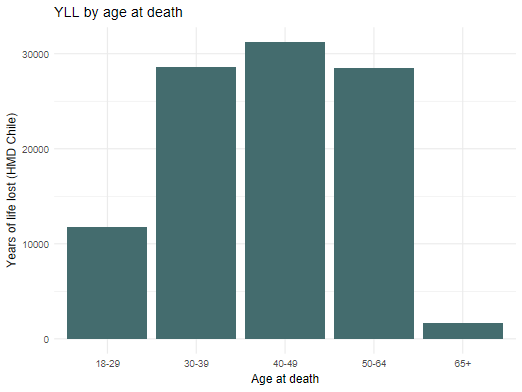


[chunk: figures] 0.6 sec (0.0 min)


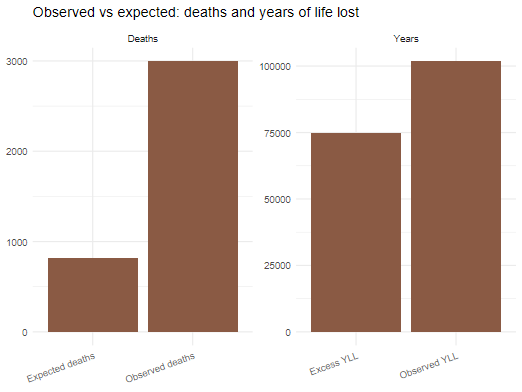

In [12]:
#| label: figures
#| message: false
#| fig-width: 8
#| fig-height: 4.5
.t0 <- proc.time()
g1 <- ggplot(by_age, aes(agecat, yll_hmd_total)) +
  geom_col(fill = "#446C6E") +
  labs(x = "Age at death", y = "Years of life lost (HMD Chile)",
       title = "YLL by age at death") + theme_minimal(base_size = 12)
print(g1)

ed <- data.frame(measure = c("Observed deaths","Expected deaths",
                             "Observed YLL","Excess YLL"),
                 value = c(excess$observed_deaths, excess$expected_deaths,
                           excess$yll_observed, excess$yll_excess),
                 panel = c("Deaths","Deaths","Years","Years"))
g2 <- ggplot(ed, aes(measure, value)) + geom_col(fill = "#8A5A44") +
  facet_wrap(~panel, scales = "free") +
  labs(x = NULL, y = NULL, title = "Observed vs expected: deaths and years of life lost") +
  theme_minimal(base_size = 12) + theme(axis.text.x = element_text(angle = 20, hjust = 1))
print(g2)
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "figures", .elapsed["elapsed"], .elapsed["elapsed"]/60))


## 11. Interpretation and limitations

- **Descriptive, not causal.** All quantities are burden comparisons against a general-population
  benchmark. The excess YLL and its fraction are **not** population attributable fractions; reading
  them causally would require assuming the cohort would revert to national mortality absent SUD,
  which this design does not support.
- **Within-window, not lifetime.** Follow-up runs from discharge to 31 December 2020, so deaths
  after the window are unobserved and the **total** SEYLL understates the eventual lifetime cohort
  burden and is not transportable across studies with different follow-up. The mean per death and
  the rate per 1,000 person-years of post-discharge follow-up are the exposure-normalized summaries;
  the rate is not comparable to GBD-style population YLL rates.
- **Period vs cohort life expectancy.** SEYLL uses period `e(x)` (2010-2020 rates held fixed), a
  conservative comparator below cohort/generation life expectancy.
- **General-population `e(x)`.** Remaining years are valued at the general population's expectation,
  not these higher-risk individuals'; SEYLL and excess YLL are therefore upper bounds on years that
  would actually have been lived, and the excess-YLL counterfactual (general-population survival for
  the excess deaths) likely overstates the absolute excess.
- **Conditioned on surviving to discharge.** Deaths during treatment are excluded by design (this is
  post-discharge mortality, consistent with the SMR via delayed entry); in-treatment deaths, often
  younger and acute, are not counted, so YLL is a lower bound for the full admission population.
- **Uncertainty.** SEYLL intervals are person-level bootstrap (superpopulation sampling of who dies
  and at what age, conditional on the observed follow-up structure); the national reference life
  table is treated as known and its uncertainty is not propagated. The excess-YLL interval is
  Poisson with an overdispersion (phi) scaling.
- **SMR coherence.** The pipeline reproduces SMR = 3.65; the e(x)-weighted excess fraction (about
  73%) sits just above the count analogue \((\mathrm{SMR}-1)/\mathrm{SMR}\approx 73\%\) because
  excess mortality concentrates at younger, higher-`e(x)` ages.

## 12. Consolidated results object

In [13]:
#| label: save-bundle
#| message: false
.t0 <- proc.time()
yll_all <- list(smr_check = smr_check, overall = overall, excess = excess,
                by_sex = by_sex, by_age = by_age, boot_ci = boot_ci,
                n_cohort = N_cohort, n_deaths = N_deaths, person_years = PY_tot,
                built_on = as.character(Sys.time()))
rds(yll_all, "yll_all_results")
cat("\nHeadline:\n")
cat(sprintf("  SEYLL (HMD Chile)  = %s years (mean %.1f/death; %.0f-%.0f)\n",
            format(round(overall$total_yll[1]), big.mark=","), overall$mean_yll_per_death[1],
            overall$total_lo95[1], overall$total_hi95[1]))
cat(sprintf("  SEYLL (GBD 2019)   = %s years (mean %.1f/death)\n",
            format(round(overall$total_yll[3]), big.mark=","), overall$mean_yll_per_death[3]))
cat(sprintf("  Excess YLL vs pop. = %s years (%.0f%% e-wtd / %.0f%% count; SMR=%.2f; phi=%.3f)\n",
            format(round(excess$yll_excess), big.mark=","), 100*excess$excess_fraction_eweighted,
            100*excess$excess_fraction_count, excess$smr, excess$phi))
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "save-bundle", .elapsed["elapsed"], .elapsed["elapsed"]/60))


  saved: yll_all_results_2026_06_27.rds 

Headline:
  SEYLL (HMD Chile)  = 101,730 years (mean 34.0/death; 98092-105261)
  SEYLL (GBD 2019)   = 128,785 years (mean 43.0/death)
  Excess YLL vs pop. = 74,723 years (73% e-wtd / 73% count; SMR=3.65; phi=1.000)

[chunk: save-bundle] 0.0 sec (0.0 min)


## 13. Packages used and session info

In [14]:
#| label: session-info
#| message: false
#| results: "hold"
.t0 <- proc.time()
used <- c("data.table","dplyr","tidyr","stringr","lubridate","rio",
          "popEpi","Epi","boot","knitr","ggplot2","sessioninfo")
pkg_tbl <- data.frame(package = used,
                      version = sapply(used, function(p) as.character(packageVersion(p))),
                      row.names = NULL)
knitr::kable(pkg_tbl, caption = "Packages used.")
if (requireNamespace("sessioninfo", quietly = TRUE)) print(sessioninfo::session_info())
print(sessionInfo())
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "session-info", .elapsed["elapsed"], .elapsed["elapsed"]/60))


─ Session info ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 setting  value
 version  R version 4.4.1 (2024-06-14 ucrt)
 os       Windows 11 x64 (build 26200)
 system   x86_64, mingw32
 ui       Positron
 language (EN)
 collate  Spanish_Chile.utf8
 ctype    Spanish_Chile.utf8
 tz       America/Santiago
 date     2026-06-27
 pandoc   NA
 quarto   ERROR: Unknown command "TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpQDW1An/filec1c81ac84b11". Did you mean command "create"? @ C:\\PROGRA~1\\Quarto\\bin\\quarto.exe

─ Packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 package      * version    date (UTC) lib source
 abind          1.4-8      2024-09-12 [1] CRAN (R 4.4.1)
 backports      1.5.0      2024-05-23 [1]

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpQDW1An/filec1c81ac84b11 -V' had status 1


R version 4.4.1 (2024-06-14 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default


locale:
[1] LC_COLLATE=Spanish_Chile.utf8  LC_CTYPE=Spanish_Chile.utf8    LC_MONETARY=Spanish_Chile.utf8 LC_NUMERIC=C                   LC_TIME=Spanish_Chile.utf8    

time zone: America/Santiago
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggplot2_4.0.3     boot_1.3-31       Epi_2.59          popEpi_0.4.14     rio_1.2.3         lubridate_1.9.4   stringr_1.6.0     tidyr_1.3.1       dplyr_1.1.4       data.table_1.17.8

loaded via a namespace (and not attached):
 [1] gtable_0.3.6        xfun_0.51           rstatix_0.7.3       etm_1.1.2           lattice_0.22-6      numDeriv_2016.8-1.1 vctrs_0.6.5         tools_4.4.1         generics_0.1.4     
[10] parallel_4.4.1      tibble_3.3.0        pkgconfig_2.0.3     R.oo_1.27.0         Matrix_1.7-0     